<a href="https://colab.research.google.com/github/franciscoweitzman-cyber/aps_francisco_weitzman/blob/main/TS5/TS5_WEITZMAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Semanal N° 5
## Por: Francisco Weitzman
### UNSAM


## Introducción
En la cotideaneidad trabajamos con señales reales, las que trabajamos día a día como lo pueden ser un audio de Whatsapp, un archivo .wav de música, o aplicaciones más técnicas como el análisis de un Electrocardiograma o un Electroencefalograma, señales de radio del espacio exterior o apuntando nuestros instrumentos para el otro lado midiendo señales sísmicas de nuestro planeta. Todas estas comparten una característica, y es que no están en el plano determinista, sino que son sistemas probabilisticos. Esto se debe a que ni las fuentes emisoras de señal son perfectas, ni el medio en el cual se propagan, ni nuestros instrumentos de medición. Esto es, no son Lineales como veníamos asumiendo hasta ahora. En un sistema lineal, una perturbación resultante se puede entender como la suma de dos perturbaciones que la generaron, y si se conocen las perturbaciones que la iniciaron, se puede estudiar la resultante analizando las perturbaciones individuales por separado. Acá estamos teniendo en cuenta que si yo perturbo a un sistema, no va a responder linealmente. Por otro lado, el ruido aportado por cada eslabón en la vida de una señal también tenemos que poder distinguir de alguna manera. Así como nuestro cerebro puede distinguir (de manera increíble para mí) lo que me está diciendo una persona en un aula llena de otros diálogos y otros ruidos, o cómo podemos distinguir distintos instrumentos en una canción que escuchamos por el celular o en el Teatro Colón a 20m de distancia, deberíamos ser capaces con nuestra tecnología de separar las señales que son de nuestro interés, y así es como distinguimos por ejemplo un descubrimiento científico de una simple medición.

Para eso existe el Periodograma, que es una estimación espectral de potencia (PSD por sus siglas en inglés). Este se define como:

$S_{xx}(ω,N)=\frac{1}{N}|\sum_{0}^{N-1}X[n]*e^{-jωn}|^2$


Vemos que se consigue a través de la DTFT. Ahora bien, si bien se considera que este es el "verdadero" estimador de nuestro PSD, no es un gran estimador ya que no mejora la varianza a medida que aumenta la cantidad de muestras, aunque sea asintóticamente insesgado, por lo que no es un gran estimador. Por eso, hice uso del método de Welch.

Este consiste en promediar periodogramas con el fin de reducir su varianza. La forma en que lo logra es mediante la toma de M segmentos de tamaño L de muestras y de un solapamiento D. Su fórmula para tiempo discreto es:

$P_W[k, L, D, M] = \left. P_W(\omega, L, D, M) \right|_{\omega = 2\pi k / L}=$

$
= \frac{\frac{1}{M} \sum_{m=0}^{M-1} \left( \left| \sum_{n=0}^{L-1} x[n+mD] w_L[n] e^{-j2\pi kn/L} \right|^2 \right)}{\sum_{n=0}^{L-1} w_L^2[n]}
 $

 $= \frac{\frac{1}{M} \sum_{m=0}^{M-1} \left( \left| \text{DFT}_L (x[n+mD] w_L[n]) \right|^2 \right)}{\sum_{n=0}^{L-1} w_L^2[n]}
$

Si se elije un solapamiendo D = L/2, la varianza se puede reducir hasta un 50% con respecto al periodograma. Si se aumenta la cantidad de segmentos, se mejora la resolución porque hay menos promediado, pero por esta misma razón la varianza aumenta. El objetivo es conseguir un criterio para reducir la varianza sin perder información de nuestra señal.


En el desarrollo voy a usar las funciones de la librería scipy.

## Desarrollo
Trabajamos con el ECG sin ruido:

1.0772872468966774


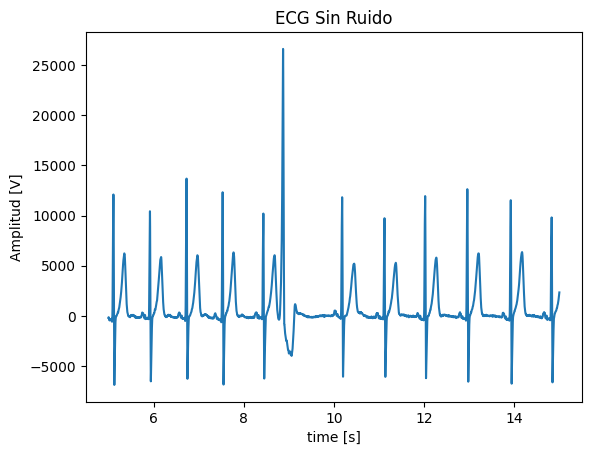

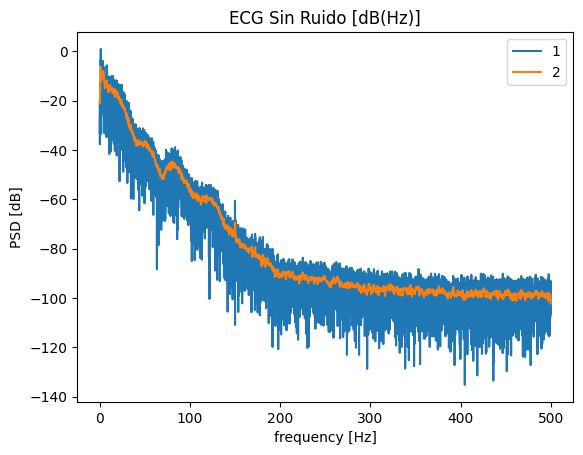

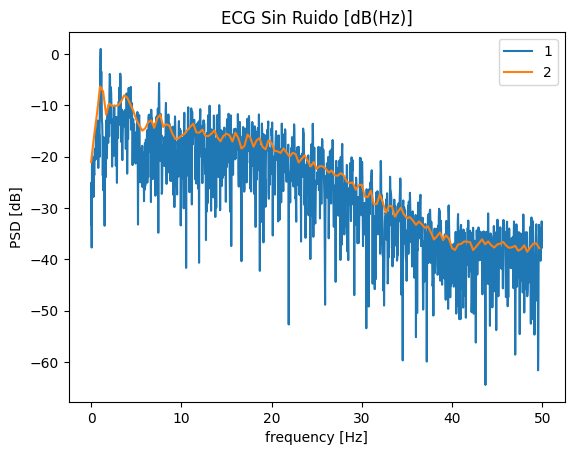

In [71]:
"""
Created on Wed Sep 30 11:22:08 2026

@author: Fran
"""
import numpy as np
from scipy import signal as sig

import matplotlib.pyplot as plt
import pandas as pd
import scipy.io as sio

import os
import soundfile as sf
from IPython.display import Audio, display

# from scipy.io.wavfile import
##################
## ECG sin ruido
##################


url_audio = 'https://github.com/franciscoweitzman-cyber/aps_francisco_weitzman/raw/refs/heads/main/TS5/ecg_sin_ruido.npy'

# 2. Descargamos el archivo desde GitHub al almacenamiento de Colab
nombre_archivo = 'ecg_sin_ruido.npy'
os.system(f'wget "{url_audio}" -O {nombre_archivo}')



fs_ecg = 1000 # Hz
ecg_one_lead = np.load('ecg_sin_ruido.npy')
tiempo_ecg = np.arange(0,len(ecg_one_lead))/fs_ecg

var_ECG = np.var(ecg_one_lead) # Energia de la señal en el tiempo
f_ecg, PDS_ecg = sig.welch(ecg_one_lead, fs_ecg, nperseg = len(ecg_one_lead))
f_ecg2, PDS_ecg2 = sig.welch(ecg_one_lead, fs_ecg, nperseg = len(ecg_one_lead)/10)
# Normalizamos gráfico en dB
var_ECG = np.var(ecg_one_lead) # Energia de la señal en el tiempo
pds_ecg_db = 10* (np.log10(PDS_ecg)) - 10*np.log10(var_ECG)
pds_ecg2_db = 10* (np.log10(PDS_ecg2)) - 10*np.log10(var_ECG)
# Análisis de Energía
df = f_ecg2[2]-f_ecg2[1]
en_pds_ecg2 = np.sum(PDS_ecg2)*df
print(en_pds_ecg2/var_ECG)

plt.figure()
plt.title("ECG Sin Ruido")
plt.xlabel('time [s]')
plt.ylabel('Amplitud [V]')
plt.plot(tiempo_ecg[5000:15000], ecg_one_lead[5000:15000])
plt.show()

plt.figure()
plt.title("ECG Sin Ruido [dB(Hz)]")
plt.xlabel('frequency [Hz]')
plt.ylabel('PSD [dB]')
plt.plot(f_ecg, pds_ecg_db, label = '1')
plt.plot(f_ecg2, pds_ecg2_db, label = '2')
plt.legend(loc='upper right')
plt.show()

plt.figure()
plt.title("ECG Sin Ruido [dB(Hz)]")
plt.xlabel('frequency [Hz]')
plt.ylabel('PSD [dB]')
plt.plot(f_ecg[:len(f_ecg)//10], pds_ecg_db[:len(f_ecg)//10], label = '1')
plt.plot(f_ecg2[:len(f_ecg2)//10], pds_ecg2_db[:len(f_ecg2)//10], label = '2')
plt.legend(loc='upper right')
plt.show()

Como podemos ver, elegí dos curvas, una tiene L=2 y otra L=10. Como la relacion de energías de mi método de Welch es un 8% mayor a la energía de mi ECG, y la resolución se conserva incluso reduciendo el ruido, entonces conservo este valor.

### PPG

0.9884588041030492


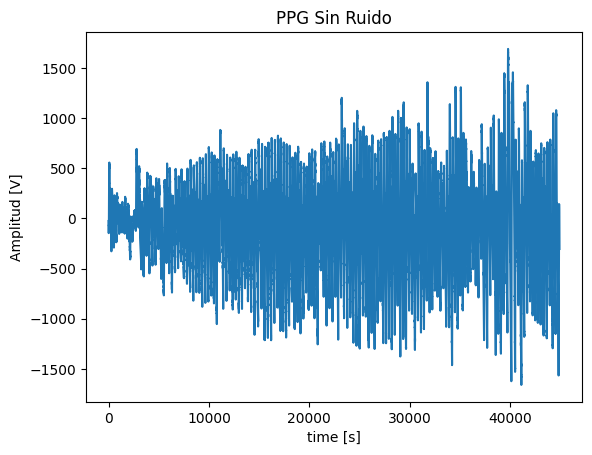

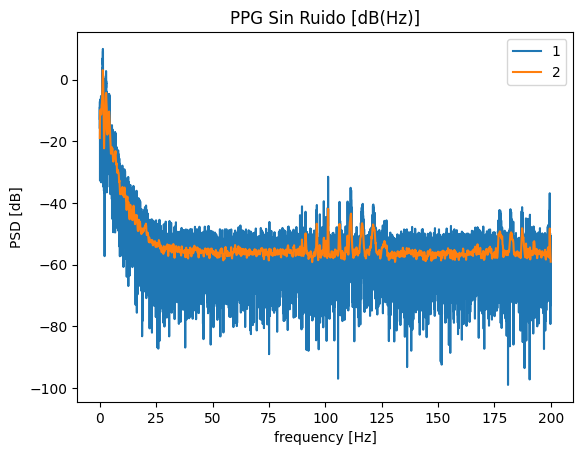

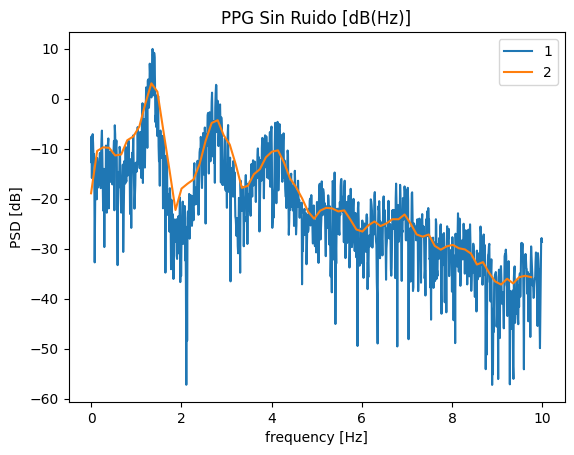

In [72]:
#%% PPG pletismografía
fs_ppg = 400 # Hz

##################
## PPG sin ruido
##################
url_ppg = 'https://github.com/franciscoweitzman-cyber/aps_francisco_weitzman/raw/refs/heads/main/TS5/ppg_sin_ruido.npy'
nombre_ppg = 'ppg_sin_ruido.npy'
os.system(f'wget "{url_ppg}" -O {nombre_ppg}')
ppg = np.load('ppg_sin_ruido.npy')
### Cargamos el archivo de audio



f_ppg, PDS_ppg = sig.welch(ppg, fs_ppg, nperseg = len(ppg)/1)
f_ppg2, PDS_ppg2 = sig.welch(ppg, fs_ppg, nperseg = len(ppg)/15)

# Normalizamos en dB
var_PPG = np.var(ppg)
pds_ppg_db = 10* (np.log10(PDS_ppg)) - 10*np.log10(var_PPG)
pds_ppg2_db = 10* (np.log10(PDS_ppg2)) - 10*np.log10(var_PPG)

# Análisis de Energía
df = f_ppg2[2]-f_ppg2[1]
en_PDS_ppg2 = np.sum(PDS_ppg2)*df
print(en_PDS_ppg2/var_PPG)

plt.figure()
plt.title("PPG Sin Ruido")
plt.xlabel('time [s]')
plt.ylabel('Amplitud [V]')
plt.plot(ppg)
plt.show()

plt.figure()
plt.title("PPG Sin Ruido [dB(Hz)]")
plt.xlabel('frequency [Hz]')
plt.ylabel('PSD [dB]')
plt.plot(f_ppg, pds_ppg_db, label = '1')
plt.plot(f_ppg2, pds_ppg2_db, label = '2')
plt.legend(loc='upper right')
plt.show()


plt.figure()
plt.title("PPG Sin Ruido [dB(Hz)]")
plt.xlabel('frequency [Hz]')
plt.ylabel('PSD [dB]')
plt.plot(f_ppg[:len(f_ppg)//20], pds_ppg_db[:len(f_ppg)//20], label = '1')
plt.plot(f_ppg2[:len(f_ppg2)//20], pds_ppg2_db[:len(f_ppg2)//20], label = '2')
plt.legend(loc='upper right')
plt.show()

La energía se mantiene un 2% por debajo de la energía de la señal del PPG y en la zona más significativa de mi espectro de potencia (0Hz-5Hz) conserva una buena relación, entonces considero este un buen criterio para estimar mi PSD.

### Audio


0.8896506579758173
1.0007735800781699


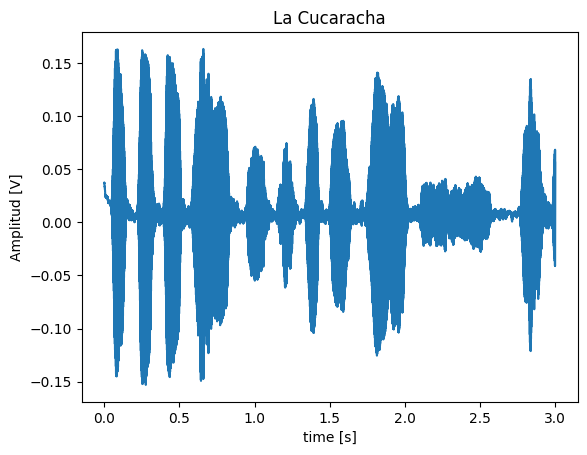

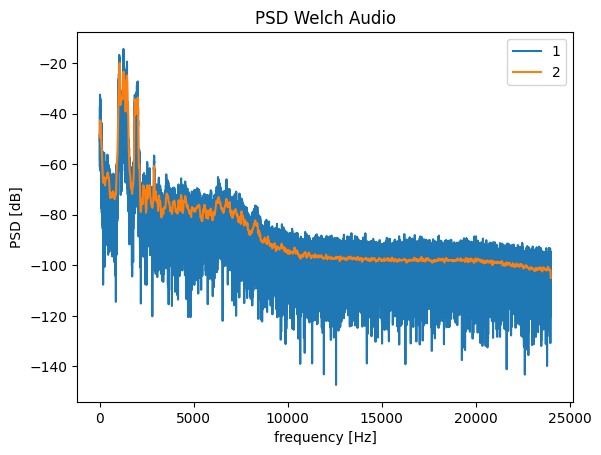

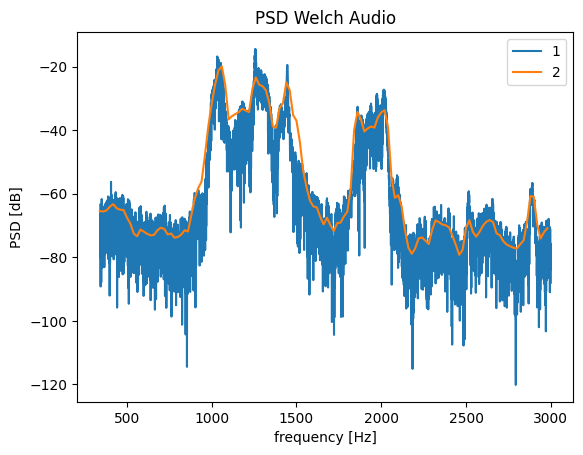

In [73]:
#%% Audio
url_audio = 'https://github.com/franciscoweitzman-cyber/aps_francisco_weitzman/raw/refs/heads/main/TS5/la_cucaracha.wav'

# 2. Lo descargamos al almacenamiento de Colab
nombre_audio = 'la_cucaracha.wav'
os.system(f'wget "{url_audio}" -O {nombre_audio}')
fs_audio, wav_data = sio.wavfile.read('la_cucaracha.wav')
nn = np.arange(0,len(wav_data))
tt = nn/(fs_audio)

plt.figure()
plt.title("La Cucaracha")
plt.xlabel('time [s]')
plt.ylabel('Amplitud [V]')
plt.plot(tt, wav_data)
#nperseg = cantidad de muestras por segmento (promedio de cuantas muestras. No se mide en muestras si no cantidad de segmentos por audio/archivo)
frecuencias, periodograma = sig.welch(wav_data,fs_audio, nperseg = len(wav_data))
frecuencias2, periodograma2 = sig.welch(wav_data,fs_audio, nperseg = len(wav_data)/60)

periodograma_db = 10* (np.log10(periodograma)) # No va al cuadrado ya que el periodograma ya me da en V**2/Hz
var = np.var(wav_data) # Energia de la señal en el tiempo
periodograma_db = 10* (np.log10(periodograma)) - 10*np.log10(var)
periodograma_db2 = 10* (np.log10(periodograma2)) - 10*np.log10(var)
""" Para llevarla a la potencia que quiera
p = 2
var_p = np.var(np.sqrt(p)*wav_data/np.sqrt(var))
"""
df = frecuencias[1]-frecuencias[0]
df2 = frecuencias2[1]-frecuencias2[0]


print(np.sum(periodograma)*df/var)
print(np.sum(periodograma2)*df2/var)


plt.figure()
plt.title("PSD Welch Audio")
plt.xlabel('frequency [Hz]')
plt.ylabel('PSD [dB]')
plt.plot(frecuencias, periodograma_db, label ="1")
plt.plot(frecuencias2, periodograma_db2,label = "2")
plt.legend(loc='upper right')
plt.show()



plt.figure()
plt.title("PSD Welch Audio")
plt.xlabel('frequency [Hz]')
plt.ylabel('PSD [dB]')
plt.plot(frecuencias[len(frecuencias)//70:len(frecuencias)//8], periodograma_db[len(frecuencias)//70:len(frecuencias)//8], label ="1")
plt.plot(frecuencias2[len(frecuencias2)//70:len(frecuencias2)//8], periodograma_db2[len(frecuencias2)//70:len(frecuencias2)//8],label = "2")
plt.legend(loc='upper right')
plt.show()

Acá podemos ver que mis frecuencias más significativas van entre los 1000Hz y los 2kHz, lo cual tiene sentido ya que el rango audible humano cae entre los 20Hz y los 20kHz, y los silbidos van en el rango de los 1000 y 2500Hz. Veamos qué pasa con los anchos de banda si pedimos que un 98% de la energía de nuestra señal esté dentro de nuestro ancho de banda para profundizar con la resolución, ya que la varianza es un indicador de escala pero no de resolución:

In [74]:
#%% Ancho de Banda
def ancho_de_banda(f, psd, energia_max):
    energia_acum = np.cumsum(psd) # Vector que guarda la info de la energia acumulada hasta el indice
    # Algo tipo: a_n = sumatoria(0,n) vector(n) donde vector(n) es el n-ésimo valor de mi vector "vector" V.L.R
    energia_acum = energia_acum/energia_acum[-1] # La ultima energía es la total, lo estoy normalizando
    f_inf = f[np.searchsorted(energia_acum, (1-energia_max)/2)]
    f_sup = f[np.searchsorted(energia_acum, 1-(1-energia_max)/2)]
    return f_inf, f_sup, f_sup-f_inf

resultados = {} # Armo un diccionario
resultados['ECG'] = ancho_de_banda(f_ecg, PDS_ecg, 0.98)
resultados['ECG2'] = ancho_de_banda(f_ecg2, PDS_ecg2, 0.98)
resultados['PPG'] = ancho_de_banda(f_ppg, PDS_ppg, 0.98)
resultados['PPG2'] = ancho_de_banda(f_ppg2, PDS_ppg2, 0.98)
resultados['Audio'] = ancho_de_banda(frecuencias, periodograma, 0.98)
resultados['Audio2'] = ancho_de_banda(frecuencias2, periodograma2, 0.98)

tablaBW = pd.DataFrame(resultados, index=['f_inf [Hz]','f_sup [Hz]','BW [Hz]']).T
print(tablaBW)

         f_inf [Hz]   f_sup [Hz]      BW [Hz]
ECG        0.700000    32.066667    31.366667
ECG2       0.333333    30.666667    30.333333
PPG        0.178098     5.547764     5.369665
PPG2       0.133601     5.477622     5.344021
Audio   1001.333333  2019.000000  1017.666667
Audio2  1000.000000  2020.000000  1020.000000


Acá armé para la la señal de audio el código y le pedí a la IA (Claude) que me genere el mismo proceso para las tres señales y que me haga una tabla.
## **Análisis ECG**
Para el ECG, vemos que para que conserve el 98% de la energía, la frecuencia mínima son 0.33Hz-0,7Hz y un máximo de $≈30Hz$. Como criterio, queremos analizar el pico que encontramos en el 1Hz con suficiente resolución. Para eso, sabiendo que:

$df_{deseado} \geq \frac{f_s}{nperseg}$ , Entonces,

$nperseg \geq 3\frac{f_s}{f_{min}}$  (5 veces como criterio mínimo de cuánto le dejo por encima de lo que tengo que leer. 5 veces más frecuente mi frecuecia de muestre que la mínima frecuencia que quiero estudiar parece correcto, además que coincide con el mínimo del ancho de banda para el PSD sin promedias (nperseg = N) ($0,2Hz≈0,33Hz$))

$nperseg = 5*\frac{1000Hz}{1Hz}= 5000$

Como "len(ecg_one_lead) = 30k", nperseg = 5k = len(ecg_one_lead)/6 resulta óptimo según este nuevo criterio. Está bastante cerca de los 1/10 que habíamos visto inicialmente.


---

## **Análisis PPG**
Pasando al PPG, vemos que las elecciones "a ojo" y varianza que realicé son bastante similares en piso de pasabandas. Como las frecuencias más importantes (al igual que en el ECG) están más cerca del piso de la banda (y en los armónicos de la frecuencia 1,5Hz) y luego cae muy rápido en magnitud el aporte de las demás frecuencias superiores, vamos a querer tener buena resolución sobre ese 1,5Hz, al menos la mitad de esa frecuencia (0,75Hz) que parece estar a 10dB menos que el pico, así que aplicaría el mismo criterio de:

$nperseg \geq 3\frac{f_s}{f_{min}}$

$nperseg = 10*\frac{400Hz}{1,5Hz}= 2666.67$

Como "len(ppg) = 44919", nperseg = 2666.67 = len(ppg)/17 resulta óptimo según este nuevo criterio. Está bastante cerca de los 1/15 que habíamos visto inicialmente.


---

## **Análisis Audio**
Por último, analizamos el archivo de audio de la flamante "la_cucaracha.wav".

Acá considero que el tratamiento es distinto, ya que si considero 10 veces más de $fs/fmin$ a nperseg, termino con segmentos del orden de los 200Hz lo cual no es aceptable ya que representa un 20% de nuestra frecuencia más baja de nuestro ancho de banda (1kHz). Entonces, el criterio que vamos a usar, aunque hay otros disponibles, es el de la mínima percepción de cambio o JND (Just Noticeable Difference). Averigué que podemos detectar cambios de 0,3% a 0,5% en frecuencias. Como nuestra escala de detección es logarítmica base 2 en frecuencia (se duplica la frecuencia y escuchamos la nota una octava más arriba), 1 cambio en la base del ancho de banda es mucho más notorio que el mismo cambio en frecuencia en el techo de banda. Por eso, vamos a calcular esa mínima diferencia en los 1000Hz y asegurarnos la resolución con un factor de 3.

$1000Hz*0.003 = 3Hz = f_{min}$

$nperseg = 3*\frac{f_s}{f_{min}}=3*\frac{48000}{3} = 48000$

$len(wavdata)/3 = 48000 = nperseg$

Entonces vamos a usar esa relación como criterio a ver cómo nos va.

Algo interesante que noté en el archivo de audio es que en nperseg = 1/60 en las iteraciones reducía mucho la varianza, aunque con no muy buena resolución. Me imagino que algo tendrá que ver con alguna frecuencia especial del audio y que justo coincide en subidas y bajadas en la media de la señal. Se podría hacer un barrido para ver qué ocurre.

0.9310375008974231


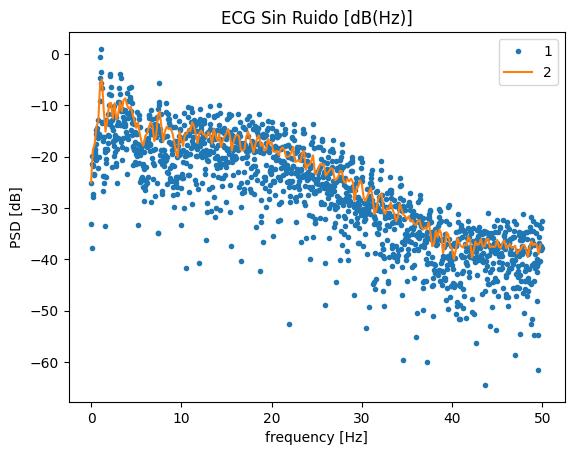

0.9903378259767045


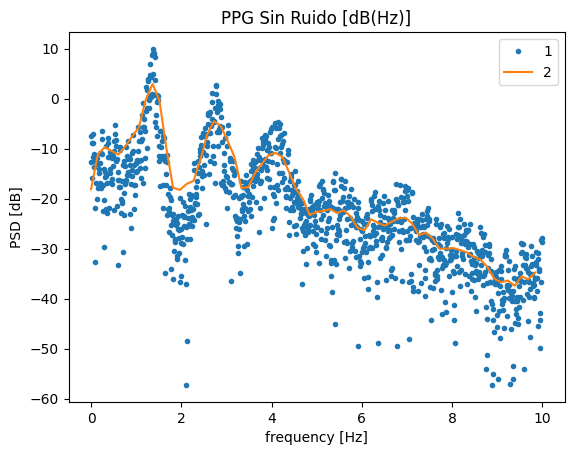

0.8896506579758173
0.9457578075433885


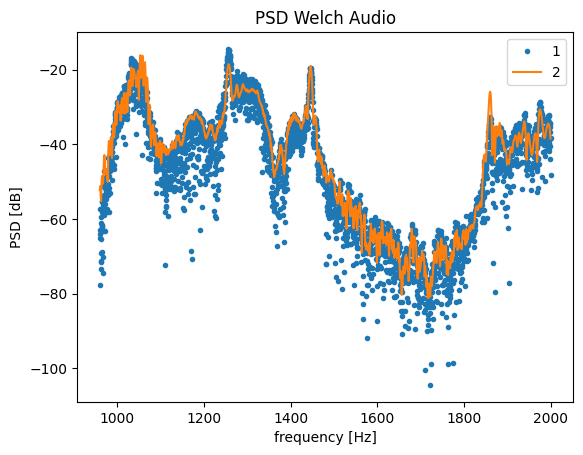

In [75]:
#__________ECG___________
f_ecg, PDS_ecg = sig.welch(ecg_one_lead, fs_ecg, nperseg = len(ecg_one_lead))
f_ecg2, PDS_ecg2 = sig.welch(ecg_one_lead, fs_ecg, nperseg = len(ecg_one_lead)/6)
# Normalizamos gráfico en dB
var_ECG = np.var(ecg_one_lead) # Energia de la señal en el tiempo
pds_ecg_db = 10* (np.log10(PDS_ecg)) - 10*np.log10(var_ECG)
pds_ecg2_db = 10* (np.log10(PDS_ecg2)) - 10*np.log10(var_ECG)
# Análisis de Energía
df = f_ecg2[2]-f_ecg2[1]
en_pds_ecg2 = np.sum(PDS_ecg2)*df
print(en_pds_ecg2/var_ECG)

plt.figure()
plt.title("ECG Sin Ruido [dB(Hz)]")
plt.xlabel('frequency [Hz]')
plt.ylabel('PSD [dB]')
plt.plot(f_ecg[:len(f_ecg)//10], pds_ecg_db[:len(f_ecg)//10], '.',label = '1')
plt.plot(f_ecg2[:len(f_ecg2)//10], pds_ecg2_db[:len(f_ecg2)//10], label = '2')
plt.legend(loc='upper right')
plt.show()

#__________PPG___________
f_ppg, PDS_ppg = sig.welch(ppg, fs_ppg, nperseg = len(ppg)/1)
f_ppg2, PDS_ppg2 = sig.welch(ppg, fs_ppg, nperseg = len(ppg)/17)

# Normalizamos en dB
var_PPG = np.var(ppg)
pds_ppg_db = 10* (np.log10(PDS_ppg)) - 10*np.log10(var_PPG)
pds_ppg2_db = 10* (np.log10(PDS_ppg2)) - 10*np.log10(var_PPG)

# Análisis de Energía
df = f_ppg2[2]-f_ppg2[1]
en_PDS_ppg2 = np.sum(PDS_ppg2)*df
print(en_PDS_ppg2/var_PPG)

plt.figure()
plt.title("PPG Sin Ruido [dB(Hz)]")
plt.xlabel('frequency [Hz]')
plt.ylabel('PSD [dB]')
plt.plot(f_ppg[:len(f_ppg)//20], pds_ppg_db[:len(f_ppg)//20],  '.',label = '1')
plt.plot(f_ppg2[:len(f_ppg2)//20], pds_ppg2_db[:len(f_ppg2)//20], label = '2')
plt.legend(loc='upper right')
plt.show()

#___________Audio_________
frecuencias2, periodograma2 = sig.welch(wav_data,fs_audio, nperseg = len(wav_data)/3)
df = frecuencias[1]-frecuencias[0]
df2 = frecuencias2[1]-frecuencias2[0]
periodograma_db = 10* (np.log10(periodograma))
var = np.var(wav_data) # Energia de la señal en el tiempo
periodograma_db = 10* (np.log10(periodograma)) - 10*np.log10(var)
periodograma_db2 = 10* (np.log10(periodograma2)) - 10*np.log10(var)

print(np.sum(periodograma)*df/var)
print(np.sum(periodograma2)*df2/var)

plt.figure()
plt.title("PSD Welch Audio")
plt.xlabel('frequency [Hz]')
plt.ylabel('PSD [dB]')
plt.plot(frecuencias[len(frecuencias)//25:len(frecuencias)//12], periodograma_db[len(frecuencias)//25:len(frecuencias)//12], '.',label ="1")
plt.plot(frecuencias2[len(frecuencias2)//25:len(frecuencias2)//12], periodograma_db2[len(frecuencias2)//25:len(frecuencias2)//12],label = "2")
plt.legend(loc='upper right')
plt.show()

In [76]:
resultados = {} # Armo un diccionario
resultados['ECG2'] = ancho_de_banda(f_ecg2, PDS_ecg2, 0.98)
resultados['PPG2'] = ancho_de_banda(f_ppg2, PDS_ppg2, 0.98)
resultados['Audio2'] = ancho_de_banda(frecuencias2, periodograma2, 0.98)

tablaBW = pd.DataFrame(resultados, index=['f_inf [Hz]','f_sup [Hz]','BW [Hz]']).T
print(tablaBW)

        f_inf [Hz]   f_sup [Hz]      BW [Hz]
ECG2        0.6000    31.400000    30.800000
PPG2        0.1514     5.450416     5.299016
Audio2   1000.0000  2019.000000  1019.000000


## Conclusiones:
Fue un trabajo que me llevó mucho tiempo real y madurativo de entender, pero fui afilando la intuición y la noción de criterios. Es interesante ver que no hay criterios universales para tratar distintas señales y los análisis de su Densidad Espectral de Potencia, y cómo elegir uno. Vemos finalmente cómo coinciden los anchos de banda con lo observable y con lo esperado, y también vemos cómo la relación de energía por parseval se mantiene dentro del 93% para las 3 señales, o sea que hay una variación de menos de un orden de magnitud con esa atenuación lo cual es un buen indicio de escala.